In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# Predicting Freight Cost

**Objective:** Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

* Freight is a non-trivial component of landed cost.
* Poor freight estimates distort margin and inventory planning.
* Automating freight estimation helps procurement teams forecast true cost before invoice arrival.

In [2]:
conn = sqlite3.connect("E:\DATA ANALYST PROJECTS\Freight_Cost_ML\Data\inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type='table'",conn)

In [ ]:
tables

In [ ]:
# Loop through the values inside the 'name' column
for table in tables['name']:
    print('Table name:', table)
    df = pd.read_sql_query(f"select * from [{table}] limit 5", conn)
    display(df)

In [66]:
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [ ]:
vendor_df[['Quantity','Freight','Dollars']].corr()

In [ ]:
# Relationship between Quantity, Dollars and Freight

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(),annot =True)
plt.show()

plt.scatter(vendor_df['Quantity'],vendor_df['Freight'], color = '#f57a55')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'], color = '#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [ ]:
vendor_df['freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']

vendor_df

In [16]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [17]:
low_quantity

83.0

In [18]:
high_quantity

5100.5

In [22]:
vendor_df.loc[vendor_df['Quantity']<low_quantity, 'Freight'].mean()

2.6445303468208095

In [23]:
vendor_df.loc[vendor_df['Quantity']>high_quantity, 'freight_per_unit'].mean()

0.049077654690759046

In [67]:
X = vendor_df['Dollars']
y = vendor_df['Freight']

In [68]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0
std,34582.0,1601.0,14453.0,140234.0,714.0
min,2.0,8106.0,1.0,4.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0
50%,7240.0,10890.0,423.0,4765.0,25.0
75%,10754.0,12276.0,5100.0,44587.0,230.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)


In [70]:
X_train

2609       264.24
5527       342.48
5321       572.40
3805     68821.14
1215    604197.73
          ...    
3772      2618.27
5191     74386.98
5226        36.96
5390       644.00
860     183412.54
Name: Dollars, Length: 4434, dtype: float64

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [72]:
model1 = LinearRegression()
model1.fit(X_train,y_train)

model2 = DecisionTreeRegressor(random_state = 42)
model2.fit(X_train,y_train)

model3 = RandomForestRegressor(random_state = 42)
model3.fit(X_train,y_train)

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [59]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    # Calculate MSE first, then take the square root for RMSE
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    
    r2 = r2_score(y_test, preds) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}%")

In [60]:
evaluate_model(model1, X_test, y_test, 'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test, y_test, 'Random Forest Regression')


Linear Regression Performance:
MAE  : 24.11
RMSE : 124.72
R²   : 96.99%

Decision Tree Regression Performance:
MAE  : 32.65
RMSE : 163.74
R²   : 94.81%

Random Forest Regression Performance:
MAE  : 28.27
RMSE : 142.21
R²   : 96.08%


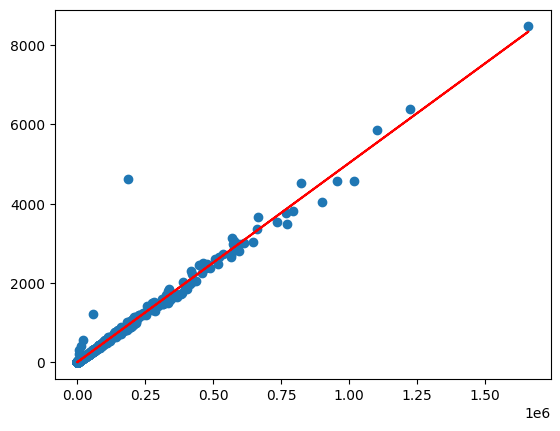

In [65]:
plt.scatter(X_test.iloc[:, 0], y_test)
plt.plot(X_test.iloc[:, 0], model1.predict(X_test), color='red')

In [61]:
input_data = {
    "Dollars": [18500,9000],
}
df = pd.DataFrame(input_data)

In [62]:
model1.predict(df)

array([97.78868161, 50.14455838])